# 🛒 Superstore Sales Analysis
## End-to-End Data Analytics Project
**Tools:** Python | Pandas | Matplotlib | Seaborn | MySQL  
**Goal:** Analyze sales performance, identify profitable segments, and uncover the impact of discounts on profitability.

In [1]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📊 Shape: 9994 rows × 21 columns


## 📋 Step 1 — Data Exploration

In [3]:
# Preview first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Dataset shape and column information
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


## 🧹 Step 2 — Data Cleaning

In [6]:
# Check missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print("\n✅ No missing values or duplicates found!")

Missing Values per Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 0

✅ No missing values or duplicates found!


In [7]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])

# Feature Engineering - Add Shipping Days column
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("✅ Date columns fixed successfully!")
print(f"📦 Average Shipping Days: {df['Shipping Days'].mean():.1f} days")
print(f"📊 Updated Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Date columns fixed successfully!
📦 Average Shipping Days: 4.0 days
📊 Updated Shape: 9994 rows × 22 columns


## 📊 Step 3 — Exploratory Data Analysis
### 3.1 Region Analysis

In [8]:
# Sales, Profit and Discount by Region
region = df.groupby("Region").agg(
    Total_Sales   = ("Sales",    "sum"),
    Total_Profit  = ("Profit",   "sum"),
    Avg_Discount  = ("Discount", "mean")
).round(2)

region["Profit_Margin_%"] = round(
    (region["Total_Profit"] / region["Total_Sales"]) * 100, 2
)

region.sort_values("Total_Sales", ascending=False)

,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
Region,,,,
West,725457.82,108418.45,0.11,14.94
East,678781.24,91522.78,0.15,13.48
Central,501239.89,39706.36,0.24,7.92
South,391721.90,46749.43,0.15,11.93


### 3.2 Category Analysis

In [9]:
category = df.groupby("Category").agg(
    Total_Sales   = ("Sales",    "sum"),
    Total_Profit  = ("Profit",   "sum"),
    Avg_Discount  = ("Discount", "mean")
).round(2)

category["Profit_Margin_%"] = round(
    (category["Total_Profit"] / category["Total_Sales"]) * 100, 2
)

category.sort_values("Total_Profit", ascending=False)

,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
Category,,,,
Technology,836154.03,145454.95,0.13,17.40
Office Supplies,719047.03,122490.80,0.16,17.04
Furniture,741999.80,18451.27,0.17,2.49


### 3.3 Sub-Category Analysis (Top 10)

In [10]:
# Top 10 Sub-Categories by Sales
top10 = df.groupby("Sub-Category").agg(
    Total_Sales   = ("Sales",    "sum"),
    Total_Profit  = ("Profit",   "sum"),
    Avg_Discount  = ("Discount", "mean")
).round(2)

top10["Profit_Margin_%"] = round(
    (top10["Total_Profit"] / top10["Total_Sales"]) * 100, 2
)

top10.sort_values("Total_Sales", ascending=False).head(10)

,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
Sub-Category,,,,
Phones,330007.05,44515.73,0.15,13.49
Chairs,328449.10,26590.17,0.17,8.10
Storage,223843.61,21278.83,0.07,9.51
Tables,206965.53,-17725.48,0.26,-8.56
Binders,203412.73,30221.76,0.37,14.86
Machines,189238.63,3384.76,0.31,1.79
Accessories,167380.32,41936.64,0.08,25.05
Copiers,149528.03,55617.82,0.16,37.20
Bookcases,114880.00,-3472.56,0.21,-3.02


## 📈 Step 4 — Data Visualization
### 4.1 Total Sales by Region

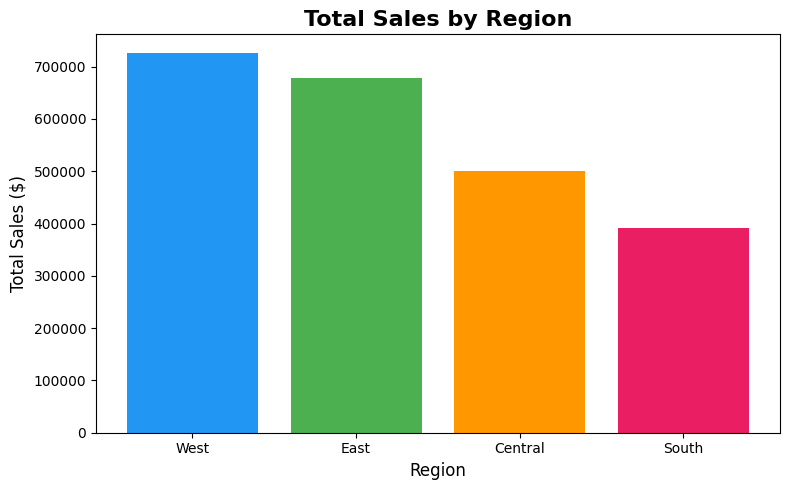

✅ Chart saved to images folder!


In [11]:
# Chart 1 - Total Sales by Region
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values,
        color=["#2196F3","#4CAF50","#FF9800","#E91E63"])
plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.tight_layout()
plt.savefig("images/sales_by_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images folder!")

### 4.2 Total Profit by Category

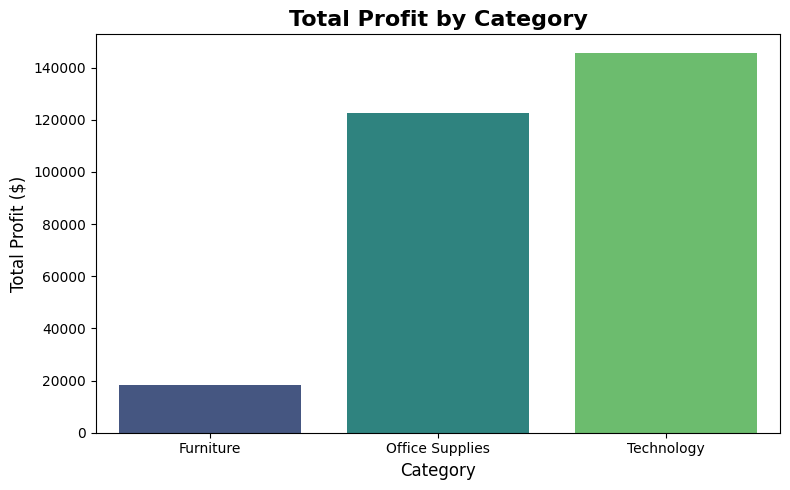

✅ Chart saved to images folder!


In [13]:
# Chart 2 - Profit by Category
category_profit = df.groupby("Category")["Profit"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=category_profit, x="Category", y="Profit",
            hue="Category", palette="viridis", legend=False)
plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
plt.tight_layout()
plt.savefig("images/profit_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images folder!")

### 4.3 Monthly Sales Trend

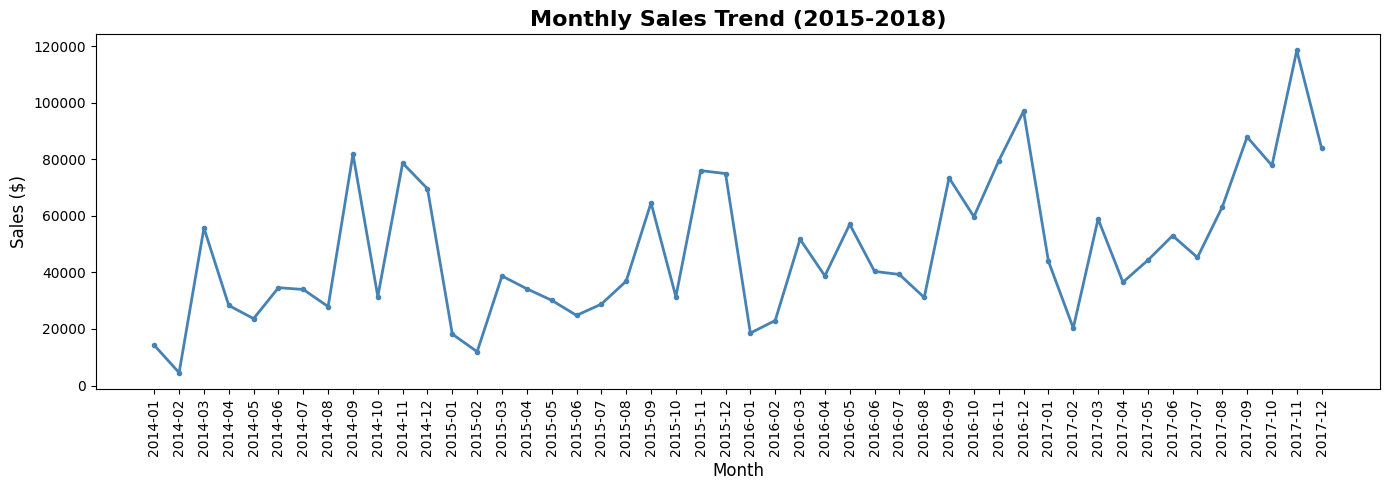

✅ Chart saved to images folder!


In [14]:
# Chart 3 - Monthly Sales Trend
df["Year-Month"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("Year-Month")["Sales"].sum().reset_index()
monthly_sales["Year-Month"] = monthly_sales["Year-Month"].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales["Year-Month"], monthly_sales["Sales"],
         color="steelblue", linewidth=2, marker="o", markersize=3)
plt.title("Monthly Sales Trend (2015-2018)", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("images/monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images folder!")

### 4.4 Discount vs Profit

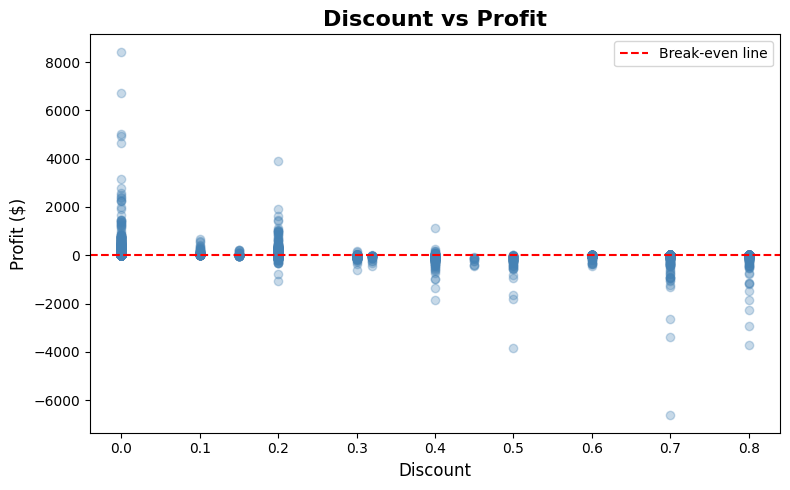

✅ Chart saved to images folder!


In [15]:
# Chart 4 - Discount vs Profit (Scatter Plot)
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"], 
            alpha=0.3, color="steelblue")
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5, label="Break-even line")
plt.title("Discount vs Profit", fontsize=16, fontweight="bold")
plt.xlabel("Discount", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("images/discount_vs_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images folder!")

## 💡 Step 5 — Key Business Insights

### 📍 Region Insights:
- **West** is the most profitable region ($108K profit, lowest 10.9% avg discount)
- **Central** gives highest discounts (24%) → lowest profit despite 3rd highest sales

### 📦 Category Insights:
- **Technology** has highest profit margin at 17.40%
- **Furniture** has only 2.49% profit margin despite 2nd highest sales
- **Office Supplies** is the hidden gem — nearly same margin as Technology!

### 🏷️ Discount Impact:
- Discount above **20% almost guarantees a loss**
- Orders with **0% discount earn up to $8,399 profit**

### 📅 Seasonality:
- Sales spike every **November-December** (holiday season)
- **February** consistently has the lowest sales

### 🚚 Operations:
- Average shipping time is **4 days**
- Tables and Bookcases are **losing money** (negative profit margin)

## 🗄️ Step 6 — MySQL Database Integration

In [1]:
# Connect Python to MySQL and import data
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="NewPassword123",
    database="superstore"
)
cursor = conn.cursor()
print("✅ Connected to MySQL successfully!")

✅ Connected to MySQL successfully!


In [2]:
# Verify data in MySQL using SQL query
query = """
SELECT Region, 
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales 
GROUP BY Region 
ORDER BY Total_Sales DESC
"""
cursor.execute(query)
results = cursor.fetchall()

print("📊 Region-wise Sales from MySQL:")
print(f"{'Region':<10} {'Total Sales':>15} {'Total Profit':>15}")
print("-" * 42)
for row in results:
    print(f"{row[0]:<10} {row[1]:>15.2f} {row[2]:>15.2f}")

cursor.close()
conn.close()
print("\n✅ MySQL connection closed successfully!")

📊 Region-wise Sales from MySQL:
Region         Total Sales    Total Profit
------------------------------------------
West             725457.82       108418.45
East             678781.24        91522.78
Central          501239.89        39706.36
South            391721.91        46749.43

✅ MySQL connection closed successfully!


## ✅ Project Summary

| Phase | Description | Status |
|---|---|---|
| Data Loading | Loaded 9,994 rows with encoding fix | ✅ Done |
| Data Cleaning | Zero missing values, zero duplicates | ✅ Done |
| Feature Engineering | Added Shipping Days column | ✅ Done |
| EDA | Region, Category, Sub-Category analysis | ✅ Done |
| Visualization | 4 professional charts created | ✅ Done |
| MySQL Integration | Data imported and validated via SQL | ✅ Done |

**Made by Prateek Sharma | GitHub: [Beleiver7](https://github.com/Beleiver7)**